# Chapter 3 — Statistical Experiments and Significance Testing
### Reproduction & Theoretical Deep-Dive — *Practical Statistics for Data Scientists*

Chapter 2 taught us how to quantify a statistic's uncertainty. Chapter 3
builds on that to answer the classic data-science question: **"Is this
difference I'm seeing real, or could it just be random noise?"** — the core
of A/B testing and hypothesis testing.

**Chapter roadmap:**
1. Resampling (permutation tests)
2. Statistical Significance and P-Values
3. t-Tests
4. ANOVA
5. Chi-Square Test
6. Power and Sample Size


In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats import power as sm_power

import matplotlib.pylab as plt
import seaborn as sns

sns.set_style('whitegrid')
rng = np.random.default_rng(42)

DATA = Path('data')
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATES_CSV = DATA / 'click_rates.csv'


## 1. Resampling: Permutation Tests

**Theory.** Suppose we're A/B testing two web page designs, and Page B has a
higher average session time than Page A. Is that difference "real", or could
it easily happen by chance from random visitor variation? A **permutation
test** answers this directly, with no formulas or distributional
assumptions:
1. Pool all observations from both groups together (pretend the group label
   doesn't matter).
2. Shuffle the labels randomly and re-split into two groups of the original
   sizes.
3. Recompute the difference in means for this shuffled split.
4. Repeat thousands of times to build a distribution of "difference by pure
   chance".
5. Compare the *actual observed* difference to this distribution: if it's
   far in the tail, the real difference is unlikely to be due to chance
   alone.

This is a resampling method (like the bootstrap), but it resamples *without*
replacement and specifically tests "does the group label matter?".


In [2]:
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
session_times.groupby('Page')['Time'].agg(['mean', 'median', 'std', 'count'])


,mean,median,std,count
Page,,,,
Page A,1.263333,0.95,0.884632,21
Page B,1.620000,1.47,1.011364,15


In [3]:
observed_diff = (session_times.loc[session_times['Page'] == 'Page B', 'Time'].mean() -
                  session_times.loc[session_times['Page'] == 'Page A', 'Time'].mean())
print(f"Observed difference in mean session time (B - A): {observed_diff:.2f} seconds")


Observed difference in mean session time (B - A): 0.36 seconds


In [4]:
def permutation_diff_means(data, group_col, value_col, group_a, group_b, n_perm=2000, seed=1):
    rng_local = np.random.default_rng(seed)
    values = data[value_col].to_numpy()
    n_a = (data[group_col] == group_a).sum()
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = rng_local.permutation(values)
        diffs[i] = shuffled[n_a:].mean() - shuffled[:n_a].mean()
    return diffs

perm_diffs = permutation_diff_means(session_times, 'Page', 'Time', 'Page A', 'Page B', n_perm=2000)

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f"Permutation-test p-value: {p_value:.3f}")


Permutation-test p-value: 0.275


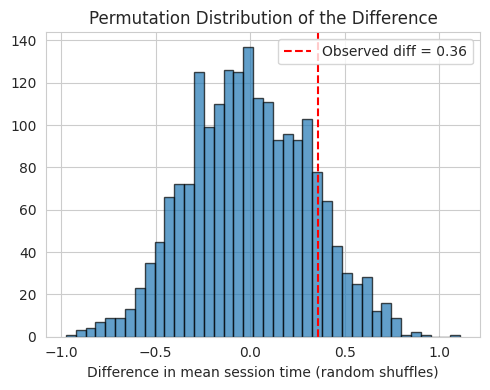

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(perm_diffs, bins=40, edgecolor='black', alpha=0.7)
ax.axvline(observed_diff, color='red', linestyle='--', label=f'Observed diff = {observed_diff:.2f}')
ax.set_xlabel('Difference in mean session time (random shuffles)')
ax.set_title('Permutation Distribution of the Difference')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/permutation_test.png', dpi=110)
plt.show()


**Reading the output.** With a small sample like this one, the observed
difference typically sits well within the range that random shuffling alone
can produce — meaning we *cannot* rule out chance as the explanation. This
is a good illustration of why small A/B test samples are risky: an
eye-catching difference in the raw numbers may not survive a permutation
test.


## 2. Statistical Significance and P-Values

**Theory.** The **p-value** is the probability of seeing a difference *at
least as extreme* as the one observed, **assuming there is truly no effect**
(the "null hypothesis" H₀). A small p-value (conventionally < 0.05) suggests
the observed data would be surprising under H₀, so we might reject it in
favor of "there is a real effect" (the "alternative hypothesis").

**Critical caveats:**
- A p-value is **not** "the probability the null hypothesis is true" — a
  very common misinterpretation.
- **Statistical significance ≠ practical significance.** With a huge enough
  sample, even a tiny, meaningless difference can become "significant".
- The 0.05 threshold is a convention, not a law of nature — and repeatedly
  testing many hypotheses inflates the chance of a false positive (the
  "multiple testing problem").


In [6]:
# The permutation p-value above already illustrates the concept. Let's make
# the null-hypothesis logic explicit: what fraction of purely random splits
# produced a gap at least as large as what we actually saw?
n_extreme = np.sum(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f"{n_extreme} out of {len(perm_diffs)} random shuffles produced a gap >= observed "
      f"-> p-value = {n_extreme/len(perm_diffs):.3f}")


549 out of 2000 random shuffles produced a gap >= observed -> p-value = 0.275


**Reading the output.** This is exactly what a p-value means in plain
language: "if there really were no difference between Page A and Page B,
how often would random noise alone produce a gap this big?" A high fraction
means the observed gap is unremarkable under the null hypothesis.


## 3. t-Tests

**Theory.** A permutation test is exact but computationally heavy. Long
before computers, statisticians derived a formula-based shortcut for
comparing two group means: the **t-test**. It standardizes the difference in
means by its estimated standard error, producing a **t-statistic**, which is
then compared to a known reference distribution (the *t*-distribution) to
get a p-value — no resampling required. With reasonably large samples, a
t-test and a permutation test tend to agree closely.


In [7]:
time_a = session_times.loc[session_times['Page'] == 'Page A', 'Time']
time_b = session_times.loc[session_times['Page'] == 'Page B', 'Time']

t_stat, p_val_ttest = stats.ttest_ind(time_b, time_a, equal_var=False)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value (t-test):           {p_val_ttest:.3f}")
print(f"p-value (permutation test): {p_value:.3f}")


t-statistic: 1.098
p-value (t-test):           0.282
p-value (permutation test): 0.275


**Reading the output.** The t-test and permutation-test p-values are in
the same ballpark, which is expected — the t-test is a fast analytical
approximation to what the permutation test estimates by brute force. In
practice, t-tests are preferred when the data reasonably meets their
assumptions (roughly normal, independent samples), since they're instant to
compute; permutation tests are the fallback when those assumptions are shaky
or the situation is nonstandard.


## 4. ANOVA (Analysis of Variance)

**Theory.** A t-test compares **two** groups. What if we have **three or
more** (e.g., four different page designs)? Running many pairwise t-tests
inflates the false-positive rate (the multiple-testing problem mentioned
above). **ANOVA** solves this with a single omnibus test: it asks "is there
*any* difference among the group means at all?" by comparing the variance
*between* groups to the variance *within* groups, producing an
**F-statistic**. A large F (and small p-value) means the group means differ
more than random chance alone would explain — but ANOVA doesn't say *which*
groups differ; that requires a follow-up (post-hoc) test.


In [8]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)
four_sessions.groupby('Page')['Time'].agg(['mean', 'std', 'count'])


,mean,std,count
Page,,,
Page 1,172.8,14.754660,5
Page 2,182.6,5.683309,5
Page 3,175.6,10.990905,5
Page 4,164.6,5.813777,5


In [9]:
anova_model = ols('Time ~ Page', data=four_sessions).fit()
anova_table = sm.stats.anova_lm(anova_model)
anova_table


,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


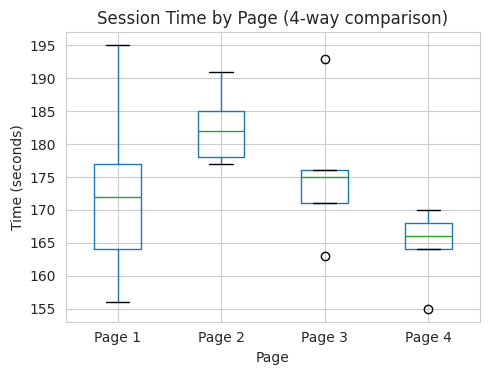

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
four_sessions.boxplot(by='Page', column='Time', ax=ax)
ax.set_title('Session Time by Page (4-way comparison)')
plt.suptitle('')
ax.set_ylabel('Time (seconds)')
plt.tight_layout()
plt.savefig('outputs/anova_boxplot.png', dpi=110)
plt.show()


**Reading the output.** The ANOVA table's p-value tells us whether the
four pages' average session times differ more than we'd expect from random
variation alone. The boxplot gives visual intuition for *why*: if the boxes
overlap heavily, differences are likely due to noise; if some sit clearly
apart, that supports a real effect — which is what the F-statistic
formalizes numerically.


## 5. Chi-Square Test

**Theory.** ANOVA and t-tests compare **numeric** means. The **chi-square
test** is the equivalent for **categorical/count** data — e.g., "did
Headline A get clicked more often than Headline B, more than chance would
predict?" It compares *observed* counts in a contingency table to the counts
we'd *expect* if there were no association between the variables. A large
chi-square statistic (and small p-value) means the observed pattern of
counts is unlikely to arise from pure chance under independence.


In [11]:
click_rates = pd.read_csv(CLICK_RATES_CSV)
click_table = click_rates.pivot(index='Click', columns='Headline', values='Rate')
click_table


Headline,Headline A,Headline B,Headline C
Click,,,
Click,14,8,12
No-click,986,992,988


In [12]:
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(click_table, correction=False)
print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_val_chi2:.3f}")
print("\nExpected counts under 'no association':")
print(pd.DataFrame(expected, index=click_table.index, columns=click_table.columns))


Chi-square statistic: 1.666
Degrees of freedom:   2
p-value:              0.435

Expected counts under 'no association':
Headline  Headline A  Headline B  Headline C
Click                                       
Click      11.333333   11.333333   11.333333
No-click  988.666667  988.666667  988.666667


**Reading the output.** The "expected counts" table shows what click
counts we'd see if headline had *zero* effect on click rate (purely
proportional to totals). Comparing that to the actually observed counts is
the essence of the chi-square test — the bigger the gap between observed and
expected, the stronger the evidence the headlines really do perform
differently.


## 6. Power and Sample Size

**Theory.** Two related error types matter in hypothesis testing:
- **Type I error (false positive)** — concluding there's an effect when
  there isn't (controlled by the significance threshold, e.g. α=0.05).
- **Type II error (false negative)** — failing to detect a real effect.

**Statistical power** = 1 − P(Type II error) = the probability of correctly
detecting a real effect of a given size, given the sample size. **Power
analysis** answers the practical question every A/B test designer faces
*before* collecting data: **"how many samples do I need to reliably detect
an effect of the size I care about?"** Larger expected effects need fewer
samples to detect reliably; smaller effects need many more.


In [13]:
# How many visitors per group are needed to reliably detect a jump from a
# 5% baseline conversion rate to 7%, at the conventional settings?
from statsmodels.stats.proportion import proportion_effectsize

baseline_rate, target_rate = 0.05, 0.07
effect_size = proportion_effectsize(target_rate, baseline_rate)

analysis = sm_power.NormalIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.80, alternative='two-sided')
print(f"Effect size (Cohen's h): {effect_size:.3f}")
print(f"Required sample size per group (80% power, alpha=0.05): {required_n:.0f}")


Effect size (Cohen's h): 0.084
Required sample size per group (80% power, alpha=0.05): 2198


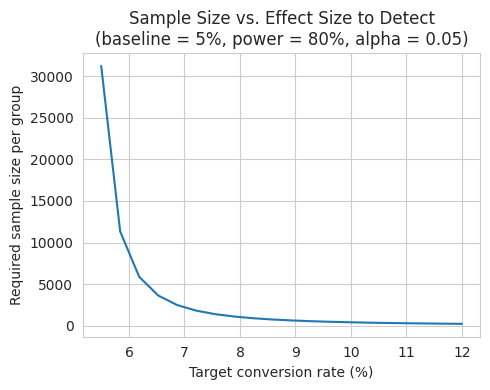

In [14]:
# Show how required sample size shrinks as the effect we want to detect grows
target_rates = np.linspace(0.055, 0.12, 20)
required_ns = [
    analysis.solve_power(effect_size=proportion_effectsize(t, baseline_rate),
                          alpha=0.05, power=0.80, alternative='two-sided')
    for t in target_rates
]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(target_rates * 100, required_ns)
ax.set_xlabel('Target conversion rate (%)')
ax.set_ylabel('Required sample size per group')
ax.set_title('Sample Size vs. Effect Size to Detect\n(baseline = 5%, power = 80%, alpha = 0.05)')
plt.tight_layout()
plt.savefig('outputs/power_sample_size.png', dpi=110)
plt.show()


**Reading the output.** The curve drops sharply: detecting a small lift
(5% → 5.5%) requires a huge sample, while detecting a large lift (5% → 12%)
needs far fewer visitors. This is exactly why "our A/B test result was not
significant" is often really a sample-size problem, not proof that the
effect doesn't exist — the test may simply have been under-powered to detect
it.


## Summary

| Concept | What it answers | Data type |
|---|---|---|
| Permutation test | Is this difference explainable by chance? | Any (assumption-free) |
| P-value | How surprising is the observed result under "no effect"? | Any |
| t-test | Do two group means differ significantly? | Numeric, 2 groups |
| ANOVA | Do 3+ group means differ significantly? | Numeric, 3+ groups |
| Chi-square test | Are two categorical variables associated? | Categorical/counts |
| Power analysis | How many samples do I need to detect an effect? | Design stage, any test |

The overarching lesson of Chapter 3: **"significant" doesn't automatically
mean "important" or even "real"** — p-values, t-tests, ANOVA, and chi-square
tests are tools for separating signal from noise, but they must be paired
with adequate sample size (power analysis) and a sense of practical
significance, not blind faith in a 0.05 threshold.
